Sonification Workshop-Adrián García Riber-2026

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Adjust the path and name of the spectrum file.
file = "miles_spec_fits_s0405.fits"

In [3]:
# Header-Check Spectrum
sp = fits.open(file)
print('\n\nHeader of the spectrum :\n\n', sp[0].header, '\n\n')



Header of the spectrum :

 SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -32 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                 4367 / length of data axis 1                          NAXIS2  =                    1 / length of data axis 2                          COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H COMMENT ----------------------------------------------------------------------  COMMENT ************************** REDUCEME HEADER ***************************  COMMENT ----------------------------------------------------------------------  HISTORY Date: 06/10/**                                                          CRPIX1  =                 1.00                                                  CRVAL1  =  

In [4]:
# Generation of arrays with the wavelengths and fluxes of the spectrum
flux = np.array(sp[0].data)
flux_norm = np.reshape(flux/(np.nanmax(flux)), (sp[0].header['NAXIS1']))


wavelengths = np.ones(sp[0].header['NAXIS1'], dtype=float)
for i in range(sp[0].header['NAXIS1']):
    wavelengths[i] = sp[0].header['CRVAL1'] + i*sp[0].header['CDELT1']
# The list "wavelengths" contains the wavelengths of the pixels.
# The list "flux" the corresponding intensities.

# Close the fits-file
sp.close()

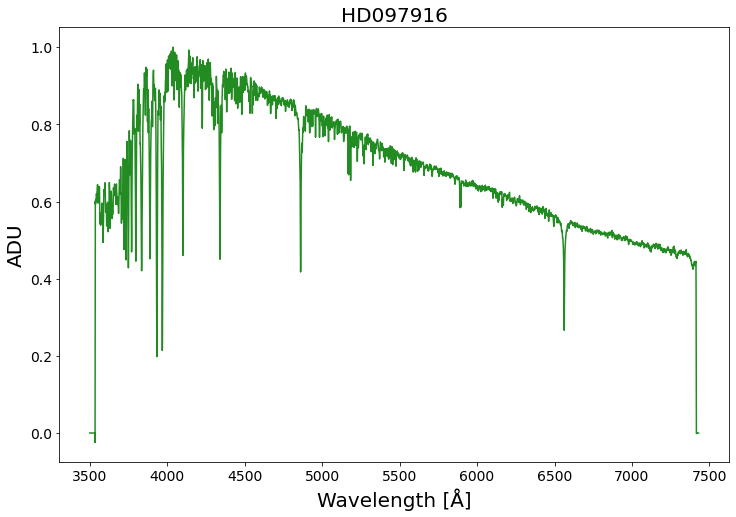

In [5]:
# Plot the spectrum
fig = plt.figure(1, figsize=(12, 8))
plt.plot(wavelengths, flux_norm, color='forestgreen')
plt.xlabel('Wavelength [Å]', size=20)
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylabel('ADU', size = 20)
plt.title(sp[0].header['OBJECT'], size=20)
plt.savefig('Spectrum-HD097916.png')
plt.show()